# Long-Term Memory Demo: Paper Recommender Agent

This notebook demonstrates how to build an agent with **long-term memory** using **Trustcall** and **LangGraph**.

## What is Long-Term Memory?

Long-term memory allows agents to remember information across multiple conversations:
- **Profile-based memory**: Tracks user preferences, interests, and history
- **Collection-based memory**: Organizes and accumulates knowledge over time

## What is Trustcall?

Trustcall is a library for structured extraction from LLMs. It:
- Automatically extracts structured data from conversations
- Validates and updates existing data
- Supports insertions and updates with `enable_inserts=True`

## What We'll Build

A paper recommender agent that:
1. Learns your research interests over time (profile-based memory)
2. Fetches relevant papers from ArXiv
3. Organizes papers by topic (collection-based memory)
4. Logs all memory changes with listeners

## Setup

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

%load_ext autoreload
%autoreload 2

In [2]:
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("OPENAI_API_KEY not found in .env file")

print("Environment variables loaded")

Environment variables loaded


In [3]:
cd ..

/Users/linafaik/Documents/projects/scientific-graph-agent


## Part 1: Understanding Trustcall

Before building the full agent, let's understand how Trustcall works with simple examples.

### Example 1: Profile-Based Memory

Profile-based memory tracks a single profile that gets updated over time.

In [ ]:
from pydantic import BaseModel, Field
from typing import List
from langchain_openai import ChatOpenAI
from trustcall import create_extractor

# 1. Define schema for user profile
class ResearchProfile(BaseModel):
    """User's research profile"""
    interests: List[str] = Field(description="Research topics of interest")
    expertise_level: str = Field(description="beginner, intermediate, or expert")
    read_papers: List[str] = Field(default=[], description="Papers already read")

# 2. Create extractor
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

profile_extractor = create_extractor(
    llm,
    tools=[ResearchProfile],
    tool_choice="ResearchProfile"
)

In [5]:
# 3. Extract initial profile
conversation = """
I'm interested in transformers and attention mechanisms.
I'm a beginner in this field.
"""

result = profile_extractor.invoke({
    "messages": [{"role": "user", "content": conversation}]
})

profile = result["responses"][0]
print("Initial profile:")
print(profile.model_dump_json(indent=2))

Initial profile:
{
  "interests": [
    "transformers",
    "attention mechanisms"
  ],
  "expertise_level": "beginner",
  "read_papers": []
}


In [6]:
# 4. Update profile with new information
new_conversation = """
I've been reading about quantum computing lately.
I think I'm getting better at this, maybe intermediate level now.
"""

updated_result = profile_extractor.invoke({
    "messages": [{"role": "user", "content": new_conversation}],
    "existing": {"ResearchProfile": profile.model_dump()}
})

updated_profile = updated_result["responses"][0]
print("\nUpdated profile:")
print(updated_profile.model_dump_json(indent=2))

print("\nMemory changes:")
print(f"- Interest: {updated_profile.interests}")
print(f"- Expertise level: beginner -> {updated_profile.expertise_level}")


Updated profile:
{
  "interests": [
    "transformers",
    "attention mechanisms",
    "quantum computing"
  ],
  "expertise_level": "intermediate",
  "read_papers": []
}

Memory changes:
- Interest: ['transformers', 'attention mechanisms', 'quantum computing']
- Expertise level: beginner -> intermediate


### Example 2: Collection-Based Memory

Collection-based memory accumulates items over time using `enable_inserts=True`.

In [35]:
# 1. Define schema for paper notes
class PaperNote(BaseModel):
    """A note about a research paper"""
    paper_title: str = Field(description="Paper title")
    key_insight: str = Field(description="Main takeaway from the paper")
    relevance: str = Field(description="Why this paper matters")

# 2. Create extractor with enable_inserts=True
collection_extractor = create_extractor(
    llm,
    tools=[PaperNote],
    tool_choice="PaperNote",
    enable_inserts=True  # KEY: allows adding new items
)

print("Collection extractor created")

Collection extractor created


In [36]:
# 3. Start with existing notes
existing_notes = [
    PaperNote(
        paper_title="Attention Is All You Need",
        key_insight="Transformers use self-attention",
        relevance="Foundation for modern LLMs"
    )
]

# Format for Trustcall: list of (id, schema_name, dict)
# FIX 1: Use unique string IDs (not just index)
existing_data = [
    (f"paper_{i+1}", "PaperNote", note.model_dump())
    for i, note in enumerate(existing_notes)
]

print("Existing collection:")
for note in existing_notes:
    print(f"- {note.paper_title}")

Existing collection:
- Attention Is All You Need


In [37]:
# 4. Add new papers to collection
conversation_with_new_papers = """
I just read two papers:

1. "Chain-of-Thought Prompting" - Shows that step-by-step reasoning 
   improves LLM accuracy on complex tasks.

2. "RAG: Retrieval-Augmented Generation" - Combines retrieval with 
   generation for better factual accuracy.
"""

result = collection_extractor.invoke({
    "messages": [{"role": "user", "content": conversation_with_new_papers}],
    "existing": existing_data
})

print("\nUpdated collection:")
for response, metadata in zip(result["responses"], result["response_metadata"]):
    is_new = metadata.get("json_doc_id") is None
    status = "NEW" if is_new else "EXISTING"
    doc_id = metadata.get("json_doc_id", "N/A")
    
    print(f"\n[{status}] {response.paper_title}")
    print(f"  Insight: {response.key_insight}")
    print(f"  Doc ID: {doc_id}")

print(f"\nMemory changes:")
print(f"- Collection grew from {len(existing_notes)} to {len(result['responses'])} papers")


2026-02-10 12:29:18,075 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



Updated collection:

[NEW] Chain-of-Thought Prompting
  Insight: Step-by-step reasoning improves LLM accuracy on complex tasks.
  Doc ID: N/A

[NEW] RAG: Retrieval-Augmented Generation
  Insight: Combines retrieval with generation for better factual accuracy.
  Doc ID: N/A

Memory changes:
- Collection grew from 1 to 2 papers


In [29]:
# Combine existing items with new/modified items from result
existing_ids = {item[0] for item in existing_data}
new_items = []

next_id = len(existing_data)
for response, metadata in zip(result["responses"], result["response_metadata"]):
    doc_id = metadata.get("json_doc_id")
    
    if doc_id is None:  # New item
        doc_id = f"paper_{next_id}"
        next_id += 1
        new_items.append((doc_id, "PaperNote", response.model_dump()))
    else:  # Modified existing item
        new_items.append((doc_id, "PaperNote", response.model_dump()))

# Preserve unmodified existing items + add new/modified ones
updated_data = [
    item for item in existing_data if item[0] not in {x[0] for x in new_items}
] + new_items

print(f"Updated data has {len(updated_data)} papers")

Updated data has 3 papers


## Part 2: Paper Recommender Agent

Now let's build a full agent that combines both types of memory.

### Create the Graph

The graph has three nodes:
1. **ProfileManager**: Updates user profile using Trustcall
2. **Recommender**: Fetches papers from ArXiv based on profile
3. **CollectionManager**: Organizes papers by topic using Trustcall

In [30]:
from src.paper_recommender.graph import create_recommender_graph

# Create graph with memory
graph = create_recommender_graph(with_checkpointer=True)

print("Graph created with long-term memory enabled")

2026-02-10 12:26:38,072 - INFO - Paper recommender graph configured
2026-02-10 12:26:38,089 - INFO - Paper recommender graph configured


Graph created with long-term memory enabled


### Visualize the Graph

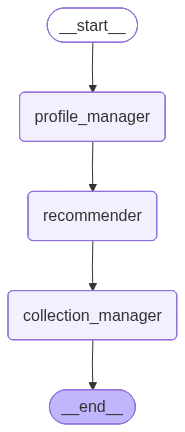


Graph flow:
START -> ProfileManager -> Recommender -> CollectionManager -> END

Memory listeners track changes after each node execution.


In [31]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

print("\nGraph flow:")
print("START -> ProfileManager -> Recommender -> CollectionManager -> END")
print("\nMemory listeners track changes after each node execution.")

### Test 1: First Query - Building Profile

The agent will:
1. Extract interests from the query
2. Fetch relevant papers
3. Organize them by topic

In [38]:
# Configuration for memory
config = {"configurable": {"thread_id": "user-123"}}

# First query
query1 = "I'm interested in transformer architectures and attention mechanisms"

print(f"Query: {query1}\n")

result1 = graph.invoke(
    {
        "query": query1,
        "llm_model": "gpt-4o-mini",
        "max_recommendations": 3
    },
    config=config
)

print("\nExecution complete")

2026-02-10 12:29:36,418 - INFO - Extracting profile from query


Query: I'm interested in transformer architectures and attention mechanisms



2026-02-10 12:29:37,422 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-10 12:29:37,430 - INFO - Profile updated: 2 interests, level: beginner
2026-02-10 12:29:37,431 - INFO - Generating recommendations
2026-02-10 12:29:37,618 - INFO - Found 3 papers
2026-02-10 12:29:37,620 - INFO - Managing paper collections
2026-02-10 12:29:41,136 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-10 12:29:41,160 - INFO - Updated collections: 3 topics



Execution complete


### Inspect Memory State

Let's see what the agent learned about us.

In [39]:
# Profile-based memory
profile = result1.get("user_profile", {})
print("USER PROFILE (Profile-Based Memory):")
print(f"  Interests: {profile.get('interests', [])}")
print(f"  Expertise level: {profile.get('expertise_level', 'N/A')}")
print(f"  Papers read: {len(profile.get('read_papers', []))}")

# Collection-based memory
collections = result1.get("collections", [])
print(f"\nPAPER COLLECTIONS (Collection-Based Memory):")
for coll in collections:
    print(f"  Topic: {coll.get('topic', 'Unknown')}")
    print(f"  Papers: {len(coll.get('paper_ids', []))}")

# Recommendations
recommendations = result1.get("recommendations", [])
print(f"\nRECOMMENDATIONS:")
for i, paper in enumerate(recommendations, 1):
    print(f"\n{i}. {paper['title']}")
    print(f"   Authors: {', '.join(paper['authors'][:2])}...")
    print(f"   Published: {paper['published']}")

USER PROFILE (Profile-Based Memory):
  Interests: ['attention mechanisms', 'transformer architectures']
  Expertise level: beginner
  Papers read: 0

PAPER COLLECTIONS (Collection-Based Memory):
  Topic: Image Generation
  Papers: 1
  Topic: Image Generation
  Papers: 1
  Topic: Quantum Computing
  Papers: 1
  Topic: Floorplan Reconstruction
  Papers: 1

RECOMMENDATIONS:

1. Autoregressive Image Generation with Masked Bit Modeling
   Authors: Qihang Yu, Qihao Liu...
   Published: 2026-02-09

2. Hybrid Method of Efficient Simulation of Physics Applications for a Quantum Computer
   Authors: Carla Rieger, Albert T. Schmitz...
   Published: 2026-02-09

3. Raster2Seq: Polygon Sequence Generation for Floorplan Reconstruction
   Authors: Hao Phung, Hadar Averbuch-Elor...
   Published: 2026-02-09


### Test 2: Second Query - Memory Persistence

The agent should remember our previous interests and combine them with new ones.

In [40]:
# Second query with SAME thread_id
query2 = "Now I want to learn about quantum computing applications"

print(f"Query: {query2}\n")
print("Using the same thread_id - memory should persist\n")

result2 = graph.invoke(
    {
        "query": query2,
        "max_recommendations": 3
    },
    config=config  # Same config = same memory
)

print("\nExecution complete")

2026-02-10 12:30:02,841 - INFO - Extracting profile from query


Query: Now I want to learn about quantum computing applications

Using the same thread_id - memory should persist



2026-02-10 12:30:04,198 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-10 12:30:04,210 - INFO - Profile updated: 3 interests, level: beginner
2026-02-10 12:30:04,212 - INFO - Generating recommendations
2026-02-10 12:30:04,295 - INFO - Found 3 papers
2026-02-10 12:30:04,296 - INFO - Managing paper collections
2026-02-10 12:30:07,863 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-10 12:30:07,886 - INFO - Updated collections: 3 topics



Execution complete


In [41]:
# Check updated profile
profile2 = result2.get("user_profile", {})
print("UPDATED PROFILE:")
print(f"  Interests: {profile2.get('interests', [])}")
print("\nMemory changes:")
print(f"  - Previous interests: {profile.get('interests', [])}")
print(f"  - New interests: {profile2.get('interests', [])}")

# Check updated collections
collections2 = result2.get("collections", [])
print(f"\nUPDATED COLLECTIONS:")
for coll in collections2:
    print(f"  Topic: {coll.get('topic', 'Unknown')}")
    print(f"  Papers: {len(coll.get('paper_ids', []))}")

print(f"\nTotal topics tracked: {len(collections2)}")

UPDATED PROFILE:
  Interests: ['attention mechanisms', 'transformer architectures', 'quantum computing applications']

Memory changes:
  - Previous interests: ['attention mechanisms', 'transformer architectures']
  - New interests: ['attention mechanisms', 'transformer architectures', 'quantum computing applications']

UPDATED COLLECTIONS:
  Topic: Image Generation
  Papers: 1
  Topic: Image Generation
  Papers: 1
  Topic: Quantum Computing
  Papers: 1
  Topic: Floorplan Reconstruction
  Papers: 1
  Topic: Image Generation
  Papers: 1
  Topic: Quantum Computing
  Papers: 1
  Topic: Floorplan Reconstruction
  Papers: 1

Total topics tracked: 7


### Test 3: New User - Fresh Memory

Using a different thread_id starts with empty memory.

In [ ]:
# New user with different thread_id
config_new_user = {"configurable": {"thread_id": "user-456"}}

query3 = "I'm interested in reinforcement learning"

print(f"Query: {query3}")
print("New thread_id - fresh memory\n")

result3 = graph.invoke(
    {
        "query": query3,
        "max_recommendations": 3
    },
    config=config_new_user
)

profile3 = result3.get("user_profile", {})
print("\nNEW USER PROFILE:")
print(f"  Interests: {profile3.get('interests', [])}")

2026-02-10 12:30:49,066 - INFO - Extracting profile from query


Query: I'm interested in reinforcement learning
New thread_id - fresh memory



2026-02-10 12:30:49,770 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-10 12:30:49,782 - INFO - Profile updated: 1 interests, level: beginner
2026-02-10 12:30:49,783 - INFO - Generating recommendations
2026-02-10 12:30:50,234 - INFO - Found 3 papers
2026-02-10 12:30:50,238 - INFO - Managing paper collections
2026-02-10 12:30:51,529 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-10 12:30:51,552 - INFO - Updated collections: 1 topics



NEW USER PROFILE:
  Interests: ['reinforcement learning']

Notice: Only reinforcement learning, no transformer/quantum topics


## Part 4: Running in LangGraph Studio

To interact with this agent in LangGraph Studio:

### 1. Ensure langgraph.json is configured

Your project should have a `langgraph.json` file at the root:

```json
{
  "graphs": {
    "paper_recommender": "src/paper_recommender/graph.py:graph"
  },
  "env": ".env"
}
```

### 2. Start LangGraph Studio

```bash
langgraph dev
```

This will start a local server at `http://127.0.0.1:2024`

### 3. Open in Browser

Navigate to:
```
https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
```

### 4. Interact with the Agent

- Click "New Thread" to start a conversation
- Type queries like: "I'm interested in transformers"
- Watch the graph execute in real-time
- Inspect state after each node to see memory updates
- Use the same thread to test memory persistence

### 5. Debugging Features

Studio provides:
- Visual graph execution flow
- State inspector (see profile and collections)
- Memory persistence across conversations
- Step-by-step debugging
- Time-travel through conversation history

## Summary

### What We Learned

1. **Trustcall Basics**
   - Profile-based memory: Single profile that updates
   - Collection-based memory: Growing collection with `enable_inserts=True`

2. **LangGraph Integration**
   - Checkpointer: Persists state across conversations
   - Listeners: Track memory changes with `with_listeners`
   - Thread IDs: Separate memory per user

3. **Memory Architecture**
   - ProfileManager node: Extracts and updates user profile
   - Recommender node: Uses profile to fetch relevant papers
   - CollectionManager node: Organizes papers by topic

### Key Takeaways

- Use Pydantic schemas for structured memory
- Trustcall handles updates automatically
- Listeners make memory changes explicit
- Checkpointer enables conversation persistence

### Next Steps

- Try different queries and watch memory evolve
- Experiment with expertise level changes
- Add more sophisticated collection logic
- Deploy in LangGraph Studio for production use